# NLP & representation learning: Neural Embeddings, Text Classification


To use statistical classifiers with text, it is first necessary to vectorize the text. In the first practical session we explored the **Bag of Word (BoW)** model.

Modern **state of the art** methods uses  embeddings to vectorize the text before classification in order to avoid feature engineering.

## [Dataset](https://thome.isir.upmc.fr/classes/RITAL/json_pol.json)


## "Modern" NLP pipeline

By opposition to the **bag of word** model, in the modern NLP pipeline everything is **embeddings**. Instead of encoding a text as a **sparse vector** of length $D$ (size of feature dictionnary) the goal is to encode the text in a meaningful dense vector of a small size $|e| <<< |D|$.


The raw classification pipeline is then the following:

```
raw text ---|embedding table|-->  vectors --|Neural Net|--> class
```


### Using a  language model:

How to tokenize the text and extract a feature dictionnary is still a manual task. To directly have meaningful embeddings, it is common to use a pre-trained language model such as `word2vec` which we explore in this practical.

In this setting, the pipeline becomes the following:
```
      
raw text ---|(pre-trained) Language Model|--> vectors --|classifier (or fine-tuning)|--> class
```


- #### Classic word embeddings

 - [Word2Vec](https://arxiv.org/abs/1301.3781)
 - [Glove](https://nlp.stanford.edu/projects/glove/)


- #### bleeding edge language models techniques (see next)

 - [UMLFIT](https://arxiv.org/abs/1801.06146)
 - [ELMO](https://arxiv.org/abs/1802.05365)
 - [GPT](https://blog.openai.com/language-unsupervised/)
 - [BERT](https://arxiv.org/abs/1810.04805)






### Goal of this session:

1. Train word embeddings on training dataset
2. Tinker with the learnt embeddings and see learnt relations
3. Tinker with pre-trained embeddings.
4. Use those embeddings for classification
5. Compare different embedding models

## STEP 0: Loading data

In [1]:
import json
from collections import Counter

# Loading json
file = './json_pol.json'
with open(file,encoding="utf-8") as f:
    data = json.load(f)


# Quick Check
counter = Counter((x[1] for x in data))
print("Number of reviews : ", len(data))
print("----> # of positive : ", counter[1])
print("----> # of negative : ", counter[0])
print("")
print(data[0]) # 1 pos 0 neg

Number of reviews :  25000
----> # of positive :  12500
----> # of negative :  12500

['Although credit should have been given to Dr. Seuess for stealing the story-line of "Horton Hatches The Egg", this was a fine film. It touched both the emotions and the intellect. Due especially to the incredible performance of seven year old Justin Henry and a script that was sympathetic to each character (and each one\'s predicament), the thought provoking elements linger long after the tear jerking ones are over. Overall, superior acting from a solid cast, excellent directing, and a very powerful script. The right touches of humor throughout help keep a "heavy" subject from becoming tedious or difficult to sit through. Lastly, this film stands the test of time and seems in no way dated, decades after it was released.', 1]


In [64]:
data_text = [x[0] for x in data]
data_label = [x[1] for x in data]

## Word2Vec: Quick Recap

**[Word2Vec](https://arxiv.org/abs/1301.3781) is composed of two distinct language models (CBOW and SG), optimized to quickly learn word vectors**


given a random text: `i'm taking the dog out for a walk`



### (a) Continuous Bag of Word (CBOW)
    -  predicts a word given a context
    
maximizing `p(dog | i'm taking the ___ out for a walk)`
    
### (b) Skip-Gram (SG)               
    -  predicts a context given a word
    
 maximizing `p(i'm taking the out for a walk | dog)`



   

## STEP 1: train a language model (word2vec)

Gensim has one of [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html) fastest implementation.


### Train:

In [2]:
# if gensim not installed yet
# ! pip install gensim

In [3]:
import gensim
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

text = [t.split() for t,p in data] # p is the class

# the following configuration is the default configuration
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-16 15:27:57,645 : INFO : collecting all words and their counts
2026-02-16 15:27:57,647 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-16 15:27:58,398 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-02-16 15:27:59,131 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-02-16 15:27:59,484 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-02-16 15:27:59,485 : INFO : Creating a fresh vocabulary
2026-02-16 15:27:59,802 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-02-16T15:27:59.802075', 'gensim': '4.4.0', 'python': '3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'prepare_vocab'}
2026-02-16 15:27:59,8

In [ ]:
# w2v = gensim.models.Word2Vec.load("W2v-movies.dat") # to delete

In [4]:
# Worth it to save the previous embedding
w2v.save("W2v-movies.dat")
# You will be able to reload them:
# w2v = gensim.models.Word2Vec.load("W2v-movies.dat")
# and you can continue the learning process if needed

2026-02-16 15:34:11,045 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'W2v-movies.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T15:34:11.044975', 'gensim': '4.4.0', 'python': '3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'saving'}
2026-02-16 15:34:11,048 : INFO : not storing attribute cum_table
2026-02-16 15:34:11,163 : INFO : saved W2v-movies.dat


## STEP 2: Test learnt embeddings

The word embedding space directly encodes similarities between words: the vector coding for the word "great" will be closer to the vector coding for "good" than to the one coding for "bad". Generally, [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) is the distance used when considering distance between vectors.

KeyedVectors have a built in [similarity](https://radimrehurek.com/gensim/models /keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.similarity) method to compute the cosine similarity between words

In [6]:
# is great really closer to good than to bad ?
print("great and good:",w2v.wv.similarity("great","good")) # semantic 
print("great and bad:",w2v.wv.similarity("great","bad"))
print("cat and dog:",w2v.wv.similarity("cat","dog"))
print("cat and feline:",w2v.wv.similarity("cat","feline"))

great and good: 0.79072934
great and bad: 0.49222216
cat and dog: 0.72867936
cat and feline: 0.52592677


Since cosine distance encodes similarity, neighboring words are supposed to be similar. The [most_similar](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.BaseKeyedVectors.most_similar) method returns the `topn` words given a query.

In [15]:
# The query can be as simple as a word, such as "movie"

# Try changing the word
# w2v.wv.most_similar("movie",topn=5) # 5 most similar words
# w2v.wv.most_similar("awesome",topn=5)
w2v.wv.most_similar("actor",topn=5)

[('actor,', 0.8170956373214722),
 ('actor.', 0.75283282995224),
 ('actress', 0.7457114458084106),
 ('Hopper', 0.7378983497619629),
 ('role,', 0.7170600891113281)]

But it can be a more complicated query
Word embedding spaces tend to encode much more.

The most famous exemple is: `vec(king) - vec(man) + vec(woman) => vec(queen)`

In [ ]:
# What is awesome - good + bad ?
# w2v.wv.most_similar(positive=["awesome","bad"],negative=["good"],topn=3)

w2v.wv.most_similar(positive=["actor","woman"],negative=["man"],topn=3) # do the famous exemple works for actor ?
w2v.wv.most_similar(positive=["women"],negative=["s"],topn=3) 
# Try other things like plurals for exemple.

[('men', 0.3915342092514038),
 ('females', 0.3390340209007263),
 ('women,', 0.32362112402915955)]

**To test learnt "synctactic" and "semantic" similarities, Mikolov et al. introduced a special dataset containing a wide variety of three way similarities.**

**You can download the dataset [here](https://thome.isir.upmc.fr/classes/RITAL/questions-words.txt).**

In [ ]:
out = w2v.wv.evaluate_word_analogies("questions-words.txt", case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 15:44:52,829 : INFO : Evaluating word analogies for top 300000 words in the model on questions-words.txt
2026-02-16 15:44:53,117 : INFO : capital-common-countries: 6.7% (6/90)
2026-02-16 15:44:53,377 : INFO : capital-world: 2.8% (2/71)
2026-02-16 15:44:53,499 : INFO : currency: 0.0% (0/28)
2026-02-16 15:44:54,475 : INFO : city-in-state: 0.0% (0/329)
2026-02-16 15:44:55,765 : INFO : family: 40.1% (137/342)
2026-02-16 15:44:58,426 : INFO : gram1-adjective-to-adverb: 1.9% (18/930)
2026-02-16 15:45:00,200 : INFO : gram2-opposite: 3.4% (19/552)
2026-02-16 15:45:03,659 : INFO : gram3-comparative: 21.5% (271/1260)
2026-02-16 15:45:05,283 : INFO : gram4-superlative: 8.0% (56/702)
2026-02-16 15:45:06,986 : INFO : gram5-present-participle: 17.3% (131/756)
2026-02-16 15:45:08,599 : INFO : gram6-nationality-adjective: 2.8% (22/792)
2026-02-16 15:45:12,213 : INFO : gram7-past-tense: 16.2% (204/1260)
2026-02-16 15:45:14,153 : INFO : gram8-plural: 4.9% (40/812)
2026-02-16 15:45:16,057 : IN

**When training the w2v models on the review dataset, since it hasn't been learnt with a lot of data, it does not perform very well.**


## Word2vec visualisation

In [7]:
words = list(w2v.wv.key_to_index.keys())[:200]
embeddings = [w2v.wv[word] for word in words]
len(words)

200

In [8]:
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components = 2 , random_state = 0)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

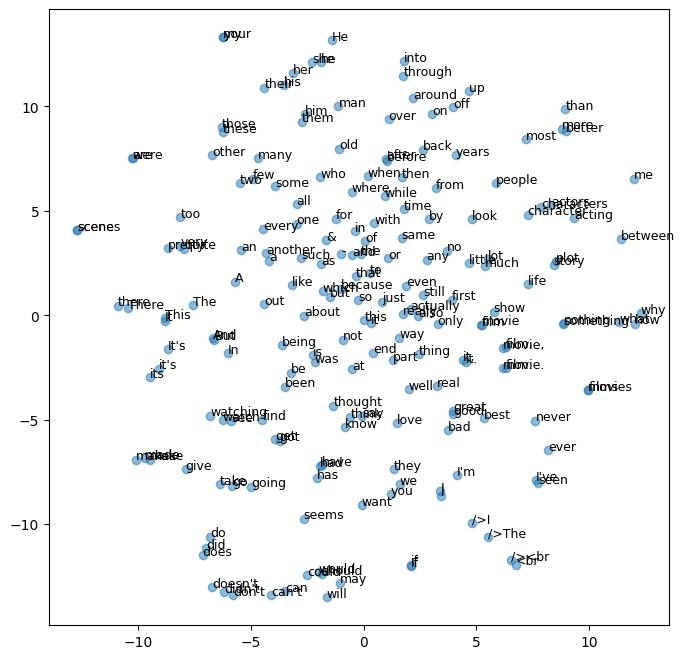

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)

for i, word in enumerate(words):  
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], word, fontsize=9)

## STEP 3: Loading a pre-trained model

In Gensim, embeddings are loaded and can be used via the ["KeyedVectors"](https://radimrehurek.com/gensim/models/keyedvectors.html) class

> Since trained word vectors are independent from the way they were trained (Word2Vec, FastText, WordRank, VarEmbed etc), they can be represented by a standalone structure, as implemented in this module.

>The structure is called “KeyedVectors” and is essentially a mapping between entities and vectors. Each entity is identified by its string id, so this is a mapping between {str => 1D numpy array}.

>The entity typically corresponds to a word (so the mapping maps words to 1D vectors), but for some models, they key can also correspond to a document, a graph node etc. To generalize over different use-cases, this module calls the keys entities. Each entity is always represented by its string id, no matter whether the entity is a word, a document or a graph node.

**You can download the pre-trained word embedding [HERE](https://thome.isir.upmc.fr/classes/RITAL/word2vec-google-news-300.dat) .**

In [10]:
import os
os.path.exists("word2vec-google-news-300.dat")

True

In [66]:
#from gensim.test.utils import get_tmpfile
import gensim.downloader as api
from gensim.models import KeyedVectors

bload = False
fname = "word2vec-google-news-300"
sdir = "" # Change


if(bload==True):
    wv_pre_trained = KeyedVectors.load(sdir+fname+".dat")
else:
    wv_pre_trained = api.load(fname)
    wv_pre_trained.save(sdir+fname+".dat")


2026-02-16 16:55:45,638 : INFO : Creating /home/franciline/gensim-data


[==================================================] 100.0% 1662.8/1662.8MB downloaded


2026-02-16 17:10:52,095 : INFO : word2vec-google-news-300 downloaded
2026-02-16 17:10:56,976 : INFO : loading projection weights from /home/franciline/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz
2026-02-16 17:12:18,835 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (3000000, 300) matrix of type float32 from /home/franciline/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz', 'binary': True, 'encoding': 'utf8', 'datetime': '2026-02-16T17:12:18.835475', 'gensim': '4.4.0', 'python': '3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'load_word2vec_format'}
2026-02-16 17:12:18,837 : INFO : KeyedVectors lifecycle event {'fname_or_handle': 'word2vec-google-news-300.dat', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-02-16T17:12:18.837016', 'gensim': '4.4.0', 'python': '3.12.2 | packaged by conda-forge | (ma

**Perform the "synctactic" and "semantic" evaluations again. Conclude on the pre-trained embeddings.**

In [ ]:
# wv_pre_trained = KeyedVectors.load("word2vec-google-news-300.dat")

In [68]:
out = wv_pre_trained.evaluate_word_analogies("questions-words.txt", case_insensitive=True)  #original semantic syntactic dataset.

2026-02-16 17:14:40,513 : INFO : Evaluating word analogies for top 300000 words in the model on questions-words.txt
2026-02-16 17:15:23,492 : INFO : capital-common-countries: 83.2% (421/506)
2026-02-16 17:18:01,768 : INFO : capital-world: 81.3% (3552/4368)
2026-02-16 17:18:31,114 : INFO : currency: 28.5% (230/808)
2026-02-16 17:20:03,177 : INFO : city-in-state: 72.1% (1779/2467)
2026-02-16 17:20:22,592 : INFO : family: 86.2% (436/506)
2026-02-16 18:14:00,102 : INFO : gram1-adjective-to-adverb: 29.2% (290/992)
2026-02-16 18:14:31,367 : INFO : gram2-opposite: 43.5% (353/812)
2026-02-16 18:15:24,360 : INFO : gram3-comparative: 91.3% (1216/1332)
2026-02-16 18:16:09,571 : INFO : gram4-superlative: 88.0% (987/1122)
2026-02-16 18:16:50,502 : INFO : gram5-present-participle: 78.5% (829/1056)
2026-02-16 18:17:53,304 : INFO : gram6-nationality-adjective: 90.2% (1442/1599)
2026-02-16 18:18:53,311 : INFO : gram7-past-tense: 65.4% (1020/1560)
2026-02-16 18:19:45,483 : INFO : gram8-plural: 87.0% (11

**Analyse**: On peut constater qu'avec le model pré-entrainer, on obtient une bien meilleure accuracy, 74% contre 12,7% pour le modèle entrainé sur la dataset du review, qui n'est pas énorme. 

## STEP 4:  sentiment classification

In the previous practical session, we used a bag of word approach to transform text into vectors.
Here, we propose to try to use word vectors (previously learnt or loaded).


### <font color='green'> Since we have only word vectors and that sentences are made of multiple words, we need to aggregate them. </font>


### (1) Vectorize reviews using word vectors:

Word aggregation can be done in different ways:

- Sum
- Average
- Min/feature
- Max/feature

#### a few pointers:

- `w2v.wv.vocab` is a `set()` of the vocabulary (all existing words in your model)
- `np.minimum(a,b) and np.maximum(a,b)` respectively return element-wise min/max

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_text, data_label, test_size=0.3, random_state=42)

In [ ]:
import numpy as np
# We first need to vectorize text:
# First we propose to a sum of them

def vectorize(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
            
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)

# classes = [pol for text,pol in train]
# X = [vectorize(text) for text,pol in train]
# X_test = [vectorize(text) for text,pol in test]
# true = [pol for text,pol in test]

X = [vectorize(text, w2v) for text in X_train]
Xtest = [vectorize(text, w2v) for text in X_test]

#let's see what a review vector looks like.
print(X[0])

[ -60.96437   419.3106    371.04108  -274.62073  -249.64633  -557.90155
  145.97752   829.0971   -444.2364   -342.72693  -450.63834  -713.61743
 -154.55415   221.9251    244.14287  -248.32153    62.64642  -165.41397
 -230.14035  -719.80237   294.32428  -119.641075  418.4335   -365.7146
  -81.607925  258.34686  -415.0204    -53.182922 -307.801     400.70905
  483.7578    137.1074    116.828285 -255.84236  -179.55595   248.86063
  115.12297  -354.01932  -358.64838  -925.75073   266.36108  -415.7068
   87.85118   427.74213   144.3888    -83.5766   -378.48206   200.65701
  239.56775   125.5763    -50.803097 -369.86108   140.28325    62.462116
 -300.0826    157.97342   -29.732641  254.0119   -216.05576   197.3048
  -52.891808  -59.737637  142.39905    86.172386 -762.6524    323.73355
  237.32803   232.48541  -532.16534   451.48743  -793.51227   447.0567
  481.0442    198.79169   -74.364975  267.70886   250.23901  -126.81216
 -120.92136  -238.28853    15.19646   194.34482   -95.38446   548.0

In [105]:
X = np.array(X)
Xtest = np.array(Xtest)

### (2) Train a classifier
as in the previous practical session, train a logistic regression to do sentiment classification with word vectors



#### Skip gram

In [ ]:
# scaling the vectors
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with sum" ,accuracy_score(y_test, preds)

('Score with sum', 0.6489333333333334)

In [ ]:
X = [vectorize(text,w2v, mean=True) for text in X_train]
Xtest = [vectorize(text, w2v,mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with mean" ,accuracy_score(y_test, preds)

('Score with mean', 0.6541333333333333)

In [ ]:
X = [vectorize(text,w2v, min=True) for text in X_train]
Xtest = [vectorize(text,w2v, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with min" ,accuracy_score(y_test, preds)

('Score with min', 0.6069333333333333)

In [ ]:
X = [vectorize(text,w2v, max=True) for text in X_train]
Xtest = [vectorize(text,w2v, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with max" ,accuracy_score(y_test, preds)

('Score with max', 0.6074666666666667)

For word 2 vec Skip gram tested, we can see that the accuracy is around 65%.

#### CBOW

In [121]:
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=0, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-23 14:56:11,872 : INFO : collecting all words and their counts
2026-02-23 14:56:11,877 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-23 14:56:12,516 : INFO : PROGRESS: at sentence #10000, processed 2301366 words, keeping 153853 word types
2026-02-23 14:56:13,225 : INFO : PROGRESS: at sentence #20000, processed 4553558 words, keeping 240043 word types
2026-02-23 14:56:13,647 : INFO : collected 276678 word types from a corpus of 5713167 raw words and 25000 sentences
2026-02-23 14:56:13,649 : INFO : Creating a fresh vocabulary
2026-02-23 14:56:14,032 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 48208 unique words (17.42% of original 276678, drops 228470)', 'datetime': '2026-02-23T14:56:14.032127', 'gensim': '4.4.0', 'python': '3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]', 'platform': 'Linux-6.14.5-100.fc40.x86_64-x86_64-with-glibc2.39', 'event': 'prepare_vocab'}
2026-02-23 14:56:14,0

In [ ]:
# to run
out = w2v.wv.evaluate_word_analogies("questions-words.txt", case_insensitive=True)  #original semantic syntactic dataset.

In [125]:
def vectorize(text,w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
            
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)

In [126]:
X = [vectorize(text, w2v) for text in X_train]
Xtest = [vectorize(text, w2v) for text in X_test]

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with sum" ,accuracy_score(y_test, preds)

('Score with sum', 0.6074666666666667)

In [ ]:
X = [vectorize(text,w2v,  mean=True) for text in X_train]
Xtest = [vectorize(text,w2v, mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with mean" ,accuracy_score(y_test, preds)

('Score with mean', 0.658)

In [128]:
X = [vectorize(text,w2v, min=True) for text in X_train]
Xtest = [vectorize(text,w2v, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with min" ,accuracy_score(y_test, preds)

('Score with min', 0.5716)

In [129]:
X = [vectorize(text,w2v, max=True) for text in X_train]
Xtest = [vectorize(text,w2v, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

"Score with max" ,accuracy_score(y_test, preds)

('Score with max', 0.5912)

#### Pretrained vectors

In [139]:
def vectorize(text, wv_pre_trained, keys, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []

    # sum
    for word in text:
        if word in keys:
            idx = wv_pre_trained.key_to_index[word] 
            vec.append(wv_pre_trained[idx])
            
    if mean:
        return np.mean(vec, axis = 0)
    if min:
        return np.min(vec, axis = 0)
    if max:
        return np.max(vec, axis = 0)
    return np.sum(vec, axis = 0)

In [137]:
keys = wv_pre_trained.key_to_index.keys()

In [141]:
X = [vectorize(text, wv_pre_trained, keys) for text in X_train]
Xtest = [vectorize(text, wv_pre_trained, keys) for text in X_test]

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with sum" ,accuracy_score(y_test, preds))

X = [vectorize(text,wv_pre_trained,keys,  mean=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained,keys, mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with mean" ,accuracy_score(y_test, preds))

X = [vectorize(text,wv_pre_trained,keys, min=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained,keys, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with min" ,accuracy_score(y_test, preds))

X = [vectorize(text,wv_pre_trained,keys, max=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained,keys, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with max" ,accuracy_score(y_test, preds))

Score with sum 0.5912
Score with mean 0.6470666666666667
Score with min 0.5865333333333334
Score with max 0.5934666666666667


performance should be worst than with bag of word (~80%). Sum/Mean aggregation does not work well on long reviews (especially with many frequent words). This adds a lot of noise.

## **Todo**:  Try answering the following questions:

- Which word2vec model works best: skip-gram or cbow
- Do pretrained vectors work best than those learnt on the train dataset ?


Of the 2 models, in general with different aggregations, the skip-gram worked the best when learning from the dataset. When aggregating with the mean, they both have close metrics. 

When testing on pretrained vectors:

## **Todo**: evaluate the same pipeline on speaker ID task (Chirac/Mitterrand)

We do the same pipeline, with skip gram, cbow, and pretrained vectors, this time on the speaker task.

In [158]:
# loading the dataset
import codecs
import re

def load_pres(fname):
    alltxts = []
    alllabs = []
    s=codecs.open(fname, 'r','utf-8') # pour régler le codage
    while True:
        txt = s.readline()
        if(len(txt))<5:
            break
        #
        lab = re.sub(r"<[0-9]*:[0-9]*:(.)>.*","\\1",txt)
        txt = re.sub(r"<[0-9]*:[0-9]*:.>(.*)","\\1",txt)
        if lab.count('M') >0:
            alllabs.append(-1)
        else:
            alllabs.append(1)
        alltxts.append(txt)

      # M = -1, C = 1
    return alltxts,alllabs

fname = "corpus.tache1.learn.utf8"
alltxts,alllabs = load_pres(fname)
text = [t.split() for t in alltxts] # p is the class

In [160]:
len(text), len(alltxts), len(alllabs)

(57413, 57413, 57413)

#### Skip gram

In [161]:
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=1, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-23 16:19:30,142 : INFO : collecting all words and their counts
2026-02-23 16:19:30,144 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-23 16:19:30,215 : INFO : PROGRESS: at sentence #10000, processed 219715 words, keeping 23930 word types
2026-02-23 16:19:30,291 : INFO : PROGRESS: at sentence #20000, processed 438525 words, keeping 35699 word types
2026-02-23 16:19:30,364 : INFO : PROGRESS: at sentence #30000, processed 649203 words, keeping 43648 word types
2026-02-23 16:19:30,435 : INFO : PROGRESS: at sentence #40000, processed 857330 words, keeping 50044 word types
2026-02-23 16:19:30,511 : INFO : PROGRESS: at sentence #50000, processed 1077423 words, keeping 55946 word types
2026-02-23 16:19:30,566 : INFO : collected 59743 word types from a corpus of 1236424 raw words and 57413 sentences
2026-02-23 16:19:30,567 : INFO : Creating a fresh vocabulary
2026-02-23 16:19:30,649 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 reta

In [194]:
def vectorize(text, w2v, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    keys = w2v.wv.key_to_index.keys()

    # sum
    for word in text:
        if word in keys:
            idx = w2v.wv.key_to_index[word] 
            vec.append(w2v.wv[idx])
            
    if mean:
        return np.mean(vec, axis = 0) if vec else np.zeros(100) # unknown word
    if min:
        return np.min(vec, axis = 0) if vec else np.zeros(100)
    if max:
        return np.max(vec, axis = 0) if vec else np.zeros(100)
    return np.sum(vec, axis = 0) if vec else np.zeros(100)

In [195]:
X_train, X_test, y_train, y_test = train_test_split(text, alllabs, test_size=0.3, random_state=42)

In [198]:
X = [vectorize(t, w2v) for t in X_train]
Xtest = [vectorize(t, w2v) for t in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with sum" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v,  mean=True) for text in X_train]
Xtest = [vectorize(text,w2v, mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with mean" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v, min=True) for text in X_train]
Xtest = [vectorize(text,w2v, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with min" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v, max=True) for text in X_train]
Xtest = [vectorize(text,w2v, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with max" , accuracy_score(y_test, preds))

Score with sum 0.8875406409660939
Score with mean 0.8765095215977705
Score with min 0.8751741755689735
Score with max 0.8732582443102648


#### CBOW

In [200]:
w2v = gensim.models.word2vec.Word2Vec(sentences=text,
                                vector_size=100, window=5,               ### here we train a cbow model
                                min_count=5,
                                sample=0.001, workers=3,
                                sg=0, hs=0, negative=5,        ### set sg to 1 to train a sg model
                                cbow_mean=1, epochs=5)

2026-02-23 16:36:08,255 : INFO : collecting all words and their counts
2026-02-23 16:36:08,258 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-02-23 16:36:08,335 : INFO : PROGRESS: at sentence #10000, processed 219715 words, keeping 23930 word types
2026-02-23 16:36:08,407 : INFO : PROGRESS: at sentence #20000, processed 438525 words, keeping 35699 word types
2026-02-23 16:36:08,476 : INFO : PROGRESS: at sentence #30000, processed 649203 words, keeping 43648 word types
2026-02-23 16:36:08,543 : INFO : PROGRESS: at sentence #40000, processed 857330 words, keeping 50044 word types
2026-02-23 16:36:08,615 : INFO : PROGRESS: at sentence #50000, processed 1077423 words, keeping 55946 word types
2026-02-23 16:36:08,671 : INFO : collected 59743 word types from a corpus of 1236424 raw words and 57413 sentences
2026-02-23 16:36:08,673 : INFO : Creating a fresh vocabulary
2026-02-23 16:36:08,754 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 reta

In [201]:
X = [vectorize(t, w2v) for t in X_train]
Xtest = [vectorize(t, w2v) for t in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with sum" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v,  mean=True) for text in X_train]
Xtest = [vectorize(text,w2v, mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with mean" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v, min=True) for text in X_train]
Xtest = [vectorize(text,w2v, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with min" ,accuracy_score(y_test, preds))
X = [vectorize(text,w2v, max=True) for text in X_train]
Xtest = [vectorize(text,w2v, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with max" , accuracy_score(y_test, preds))

Score with sum 0.8818509057129587
Score with mean 0.8743613562470971
Score with min 0.873664653971203
Score with max 0.8724454249883883


#### Pretrained

In [209]:
def vectorize(text, wv_pre_trained, keys, mean=False, min = False, max = False):
    """
    This function should vectorize one review

    input: str
    output: np.array(float)
    """ 
    vec = []
    shape_emb = wv_pre_trained[0].shape

    # sum
    for word in text:
        if word in keys:
            idx = wv_pre_trained.key_to_index[word] 
            vec.append(wv_pre_trained[idx])
            
    if mean:
        return np.mean(vec, axis = 0) if vec else np.zeros(shape_emb)
    if min:
        return np.min(vec, axis = 0) if vec else np.zeros(shape_emb)
    if max:
        return np.max(vec, axis = 0) if vec else np.zeros(shape_emb)
    return np.sum(vec, axis = 0) if vec else np.zeros(shape_emb)

In [210]:
X = [vectorize(t, wv_pre_trained, keys) for t in X_train]
Xtest = [vectorize(t, wv_pre_trained, keys) for t in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with sum" ,accuracy_score(y_test, preds))
X = [vectorize(text,wv_pre_trained, keys, mean=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained, keys, mean=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with mean" ,accuracy_score(y_test, preds))
X = [vectorize(text,wv_pre_trained, keys, min=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained, keys, min=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with min" ,accuracy_score(y_test, preds))
X = [vectorize(text,wv_pre_trained, keys, max=True) for text in X_train]
Xtest = [vectorize(text,wv_pre_trained, keys, max=True) for text in X_test]

scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)
Xtest_scaled = scaler.transform(Xtest)

clf = LogisticRegression(random_state=0, max_iter=500)
clf.fit(X_scaled, y_train)
preds = clf.predict(Xtest_scaled)

print("Score with max" , accuracy_score(y_test, preds))

Score with sum 0.8817928471899675
Score with mean 0.8711681374825825
Score with min 0.8748838829540176
Score with max 0.8746516488620529


Sur la database speaker on ne voit pas beaucoup de différence en terme de score avec différentes façon de faire les embeddings, ni sur les embeddings pré-entrainés.


**(Bonus)** To have a better accuracy, we could try two things:
- Better aggregation methods (weight by tf-idf ?)
- Another word vectorizing method such as [fasttext](https://radimrehurek.com/gensim/models/fasttext.html)
- A document vectorizing method such as [Doc2Vec](https://radimrehurek.com/gensim/models/doc2vec.html)